# Instant Model Experiments (Random Forest Classifier)

We load `instant_mock.csv`, pick the sensor features, and predict `comfortValue` classes.
We split into train/val/test and run a small grid search.

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [27]:
data_path = '../../data/processed/instant_mock.csv'
df = pd.read_csv(data_path)

target_col = 'comfortValue'
feature_cols = ['humidity', 'light', 'temperature', 'noise', 'co2']

missing_cols = [col for col in [target_col] + feature_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df = df[feature_cols + [target_col]].dropna()

# Make sure the target is a clean class label
if pd.api.types.is_numeric_dtype(df[target_col]):
    df[target_col] = df[target_col].round().astype(int)

print(f"Rows after cleaning: {len(df):,}")
display(df.head())

Rows after cleaning: 1,812


,humidity,light,temperature,noise,co2,comfortValue
0,4225.0,7.669843,25.1,7.810250,0.001916,4
1,4225.0,7.669843,25.1,7.810250,0.001916,5
2,4096.0,6.835845,25.2,7.810250,0.001976,3
3,4096.0,6.835845,25.2,7.810250,0.001976,4
4,3969.0,7.039566,25.3,7.745967,0.001938,4


In [28]:
X = df[feature_cols]
y = df[target_col]

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

Train size: 1,449
Test size:  363


In [29]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    )

grid = GridSearchCV(
    rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    )

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.3f}")

best_model = grid.best_estimator_

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy: 0.351


--- BEST MODEL ---
Computing CV predictions...
CV Accuracy: 0.351 | Precision: 0.357 | Recall: 0.351 | F1: 0.353
Test Accuracy: 0.372 | Precision: 0.398 | Recall: 0.372 | F1: 0.383


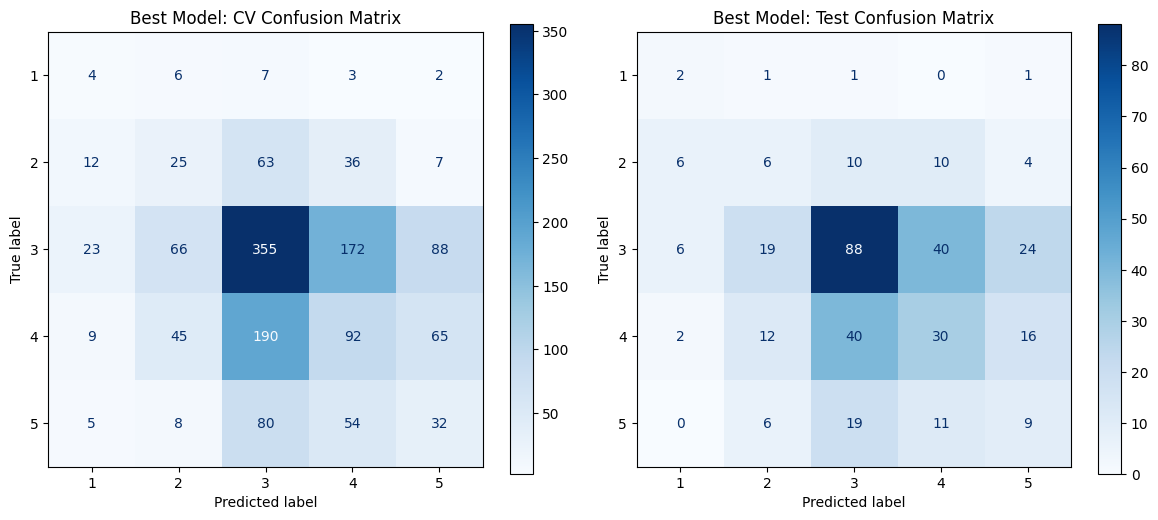

In [30]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print("--- BEST MODEL ---")
print("Computing CV predictions...")
cv_preds = cross_val_predict(grid.best_estimator_, X_train, y_train, cv=5, n_jobs=-1)
cv_acc = accuracy_score(y_train, cv_preds)
cv_prec = precision_score(y_train, cv_preds, average='weighted')
cv_rec = recall_score(y_train, cv_preds, average='weighted')
cv_f1 = f1_score(y_train, cv_preds, average='weighted')
print(f"CV Accuracy: {cv_acc:.3f} | Precision: {cv_prec:.3f} | Recall: {cv_rec:.3f} | F1: {cv_f1:.3f}")

test_preds = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average='weighted')
test_rec = recall_score(y_test, test_preds, average='weighted')
test_f1 = f1_score(y_test, test_preds, average='weighted')
print(f"Test Accuracy: {test_acc:.3f} | Precision: {test_prec:.3f} | Recall: {test_rec:.3f} | F1: {test_f1:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CV Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_train, cv_preds, cmap='Blues', ax=axes[0])
axes[0].set_title('Best Model: CV Confusion Matrix')

# Test Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, cmap='Blues', ax=axes[1])
axes[1].set_title('Best Model: Test Confusion Matrix')

plt.tight_layout()
plt.show()


--- OVERFITTING MODEL ---
Train Accuracy: 0.720 | Precision: 0.727 | Recall: 0.720 | F1: 0.707
Test Accuracy: 0.435 | Precision: 0.404 | Recall: 0.435 | F1: 0.413


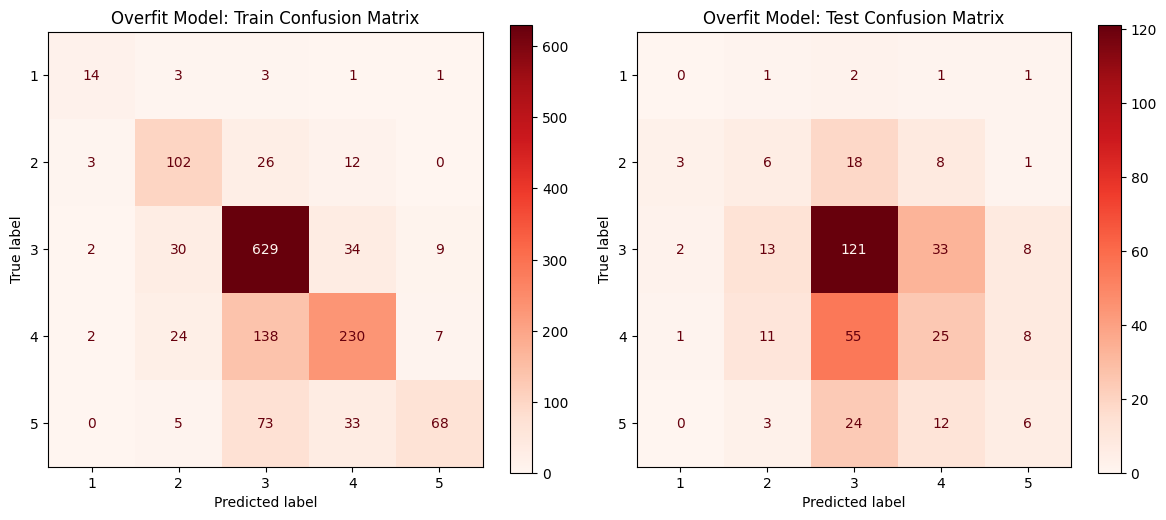

In [31]:
from sklearn.ensemble import RandomForestClassifier

print("--- OVERFITTING MODEL ---")
# Using bootstrap=False and max_depth=None ensures it memorizes the training set perfectly
overfit_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1, 
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)
overfit_model.fit(X_train, y_train)

train_preds_overfit = overfit_model.predict(X_train)
train_acc_overfit = accuracy_score(y_train, train_preds_overfit)
train_prec = precision_score(y_train, train_preds_overfit, average='weighted')
train_rec = recall_score(y_train, train_preds_overfit, average='weighted')
train_f1 = f1_score(y_train, train_preds_overfit, average='weighted')
print(f"Train Accuracy: {train_acc_overfit:.3f} | Precision: {train_prec:.3f} | Recall: {train_rec:.3f} | F1: {train_f1:.3f}")

test_preds_overfit = overfit_model.predict(X_test)
test_acc_overfit = accuracy_score(y_test, test_preds_overfit)
test_prec_overfit = precision_score(y_test, test_preds_overfit, average='weighted')
test_rec_overfit = recall_score(y_test, test_preds_overfit, average='weighted')
test_f1_overfit = f1_score(y_test, test_preds_overfit, average='weighted')
print(f"Test Accuracy: {test_acc_overfit:.3f} | Precision: {test_prec_overfit:.3f} | Recall: {test_rec_overfit:.3f} | F1: {test_f1_overfit:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train Confusion Matrix (This should show the perfect diagonal!)
ConfusionMatrixDisplay.from_predictions(y_train, train_preds_overfit, cmap='Reds', ax=axes[0])
axes[0].set_title('Overfit Model: Train Confusion Matrix')

# Test Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_preds_overfit, cmap='Reds', ax=axes[1])
axes[1].set_title('Overfit Model: Test Confusion Matrix')

plt.tight_layout()
plt.show()
